In [1]:
## Note for TA/Grader: 
## All comments start with ## are for further explanation/clarification

# Imports
library(tidyverse)
library(ggplot2)
library(scales)
library(themis)
# install.packages("tidymodels")
library(tidymodels)

# for upsample() to balance data
install.packages("groupdata2") 
library(groupdata2)

options(repr.plot.width=6, repr.plot.height=6)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor


Loading required package: recipes


Attaching package: ‘recipes’


The following object is masked from ‘package:stringr’:

    fixed


The following object is masked from ‘package:stats’:

    step


── Attaching packages ────────────────────────────────────── tidymodels 1.2.0 ──

✔ broom        1.0.6    

### Title

### Introduction

> ***(Checklist below) also moved the data description from individual submission under introduction***
- [ ] provide some relevant background information on the topic so that someone unfamiliar with it will be prepared to understand the rest of your report
- [ ] clearly state the question you tried to answer with your project
- [ ] identify and fully describe the dataset that was used to answer the question

#### Question:
Question 1: We would like to know which "kinds" of players are most likely to contribute a large amount of data so that we can target those players in our recruiting efforts.

#### Dataset Description:

1. **Players Data**
    - 196 rows (players), 9 variables
    - **Variables:**
      - `experience`: Character (player's experience level)
      - `subscribe`: Logical (whether the player subscribed to PlaiCraft's email updates)
      - `hashedEmail`: Character (unique hashed player email)
      - `played_hours`: Numeric (total hours played)
      - `name`: Character (player’s on-screen name)
      - `gender`: Character (player’s gender)
      - `age`: Numeric (player’s age)
      - `individualId`: Logical (if player has an associated ID)
      - `organizationName`: Logical (if player belongs to an organization)

2. **Sessions Data**
    - 1535 rows (sessions), 5 variables
    - **Variables:**
      - `hashedEmail`: Character (unique hashed player email)
      - `start_time`: Character (session start time)
      - `end_time`: Character (session end time)
      - `original_start_time`: Numeric (session start timestamp)
      - `original_end_time`: Numeric (session end timestamp)

**Potential Issues:**
- `individualId` and `organizationName` have only NA values, indicating irrelevance or incomplete data.
- The `gender` variable includes "Prefer not to say" and "Other" categories, which should be handled carefully as they impact analysis.
- An unbalanced gender distribution (e.g., more males) could introduce bias; further data is needed for assessment.
- `original_start_time` and `original_end_time` are numeric timestamps that need wrangling to calculate actual play time.

**Data Collection:**
The data was collected by a UBC Computer Science research group using a Minecraft server to track player actions. The aim is to analyze player behavior while managing server resources and targeting recruitment to handle the player load.

### Methods & Results
> `(Checklist For Josceline)` 
- [ ] ***describe the methods you used to perform your analysis from beginning to end that narrates the analysis code (summarize all coding and analysis done)***

> `your report should include code which:`
- [x] loads data
- [x] wrangles and cleans the data to the format necessary for the planned analysis
- [x] performs a summary of the data set that is relevant for exploratory data analysis
      related to the planned analysis
- [x] creates a visualization of the dataset that is relevant for exploratory data analysis related to the planned analysis
- [x] performs the data analysis
- [x] creates a visualization of the analysis
- [x] note: all figures should have a figure number and a legend

#### （TBC- describe the methods you used to perform your analysis from beginning to end that narrates the analysis code）
To identify players likely to contribute a large amount of data, we can use K-Nearest Neighbors (KNN) classification. The response variable is `played_hours`, while explanatory variables include `experience`, `age`, `gender`, `subscribe`, and `sessions_played` (total sessions) after merging `org_players_data` and `org_sessions_data` by `hashedEmail`. We'll preprocess the data by handling missing values, encoding/refactoring categorical variables, and scaling/centering. Players will be classified into high and low data contributors based on a threshold for `played_hours`, which is its mean. KNN will predict data contribution by comparing players to others with similar characteristics, helping to identify key traits that correlate with high playtime for targeted recruitment.

#### 1. Load data

In [2]:
# 1. Load data
players_url <- "https://drive.google.com/uc?export=download&id=1Mw9vW0hjTJwRWx0bDXiSpYsO3gKogaPz"
sessions_url <- "https://drive.google.com/uc?export=download&id=14O91N5OlVkvdGxXNJUj5jIsV5RexhzbB"
org_players_data <- read_csv(players_url)
org_sessions_data <- read_csv(sessions_url)

print("Original players data : ")
head(org_players_data)

print("Original sessions data :")
head(org_sessions_data)

Rows: 196 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, age
lgl (3): subscribe, individualId, organizationName

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): hashedEmail, start_time, end_time
dbl (2): original_start_time, original_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "Original players data : "


experience,subscribe,hashedEmail,played_hours,name,gender,age,individualId,organizationName
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<lgl>,<lgl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9,NA,NA
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17,NA,NA
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17,NA,NA
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21,NA,NA
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21,NA,NA
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17,NA,NA


[1] "Original sessions data :"


hashedEmail,start_time,end_time,original_start_time,original_end_time
<chr>,<chr>,<chr>,<dbl>,<dbl>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024 18:12,30/06/2024 18:24,1.71977e+12,1.71977e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024 23:33,17/06/2024 23:46,1.71867e+12,1.71867e+12
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024 17:34,25/07/2024 17:57,1.72193e+12,1.72193e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,25/07/2024 03:22,25/07/2024 03:58,1.72188e+12,1.72188e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,25/05/2024 16:01,25/05/2024 16:12,1.71665e+12,1.71665e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,23/06/2024 15:08,23/06/2024 17:10,1.71916e+12,1.71916e+12


#### 2. Wrangles and cleans the data to the format necessary for the planned analysis

In [3]:
# Filter individualId, organizationName that are not NA:
org_players_data |> 
  filter(!is.na(individualId) | !is.na(organizationName)) 

## turns out all NA for both individualId and organizationName, 
## thus these two variables will be excluded for analysis 
## as they do not contribute valuable data

experience,subscribe,hashedEmail,played_hours,name,gender,age,individualId,organizationName
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<lgl>,<lgl>


In [4]:
## Summarize total hours and total sessions played for each player (hashedEmail):
session_summary <- org_sessions_data |>
  mutate(
    original_start_time = as.POSIXct(original_start_time / 1000, origin = "1970-01-01", tz = "UTC"),
    original_end_time = as.POSIXct(original_end_time / 1000, origin = "1970-01-01", tz = "UTC")
  ) |>
  mutate(duration_seconds = as.numeric(difftime(original_end_time, original_start_time, units = "secs"))) |>
  mutate(duration_hours = duration_seconds / 3600) |>  # Convert seconds to hours
  group_by(hashedEmail)  |>
  summarize(played_hours_sum = sum(duration_hours), sessions_played = n())

head(session_summary)

hashedEmail,played_hours_sum,sessions_played
<chr>,<dbl>,<int>
0088b5e134c3f0498a18c7ea6b8d77b4b0ff1636fc93355ccc95b45423367832,2.777778,2
060aca80f8cfbf1c91553a72f4d5ec8034764b05ab59fe8e1cf0eee9a7b67967,0.000000,1
0ce7bfa910d47fc91f21a7b3acd8f33bde6db57912ce0290fa0437ce0b97f387,0.000000,1
0d4d71be33e2bc7266ee4983002bd930f69d304288a8663529c875f40f1750f3,11.111111,13
0d70dd9cac34d646c810b1846fe6a85b9e288a76f5dcab9c1ff1a0e7ca200b3a,2.777778,2
11006065e9412650e99eea4a4aaaf0399bc338006f85e80cc82d18b49f0e2aa4,0.000000,1


In [5]:
## As the output below shows that the summed played hours from sessions dataset 
## is different from the corresponding value in the players dataset, 
## we will use instead the played_hours from players dataset as the response variable 
## given the inconsistency, as the calculation from sessions data might be erroneous

total_played_hrs_onePlayer <- session_summary |>
    filter(hashedEmail == "f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d") |>
    select(played_hours_sum) |>
    pull()


# Print the result of summed hours of the player to verify
print("played hours of the player summed from sessions dataset: ")
print(total_played_hrs_onePlayer)  # which is greater than the played_hours 30.3 in players_data 


played_hours_same_player <- org_players_data |>
    filter(hashedEmail == "f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d") |>
    select(played_hours) |>
    pull()

print("played hours of the same player in players dataset: ")
print(played_hours_same_player)


[1] "played hours of the player summed from sessions dataset: "
[1] 33.33333
[1] "played hours of the same player in players dataset: "
[1] 30.3


#### 3. Performs a summary of the data set that is relevant for exploratory data analysis related to the planned analysis 

In [6]:
## Exclude the players that do not exist in the sessions dataset when combining, 
## Since it does not help the analysis if the players haven't played yet.
## Also exclude variables/features that are not contributive as mentioned above (or inconsistent in the case of played_hours_sum)
## (name and hashedEmail are also excluded as they are just for individual player identification). 
## Categorical variables are refactored

combined_play_data <- org_players_data |>
    right_join(session_summary, by = "hashedEmail") |>
    select(-played_hours_sum, -individualId, -organizationName, -name, -hashedEmail) |>
    mutate(experience = as_factor(experience), subscribe = as_factor(subscribe), gender = as_factor(gender)) |>
    arrange(played_hours)

head(combined_play_data)
tail(combined_play_data)
dim(combined_play_data)

experience,subscribe,played_hours,gender,age,sessions_played
<fct>,<fct>,<dbl>,<fct>,<dbl>,<int>
Veteran,FALSE,0,Male,17,1
Amateur,FALSE,0,Male,21,1
Regular,TRUE,0,Male,17,1
Amateur,TRUE,0,Female,26,1
Amateur,TRUE,0,Female,17,1
Amateur,FALSE,0,Two-Spirited,26,1


experience,subscribe,played_hours,gender,age,sessions_played
<fct>,<fct>,<dbl>,<fct>,<dbl>,<int>
Amateur,TRUE,53.9,Male,17,130
Amateur,TRUE,56.1,Male,23,310
Amateur,TRUE,150.0,Female,16,159
Regular,TRUE,178.2,Female,19,147
Regular,TRUE,218.1,Non-binary,20,95
Regular,TRUE,223.1,Male,17,219


[1] 125   6

#### 4. creates a visualization of the dataset that is relevant for exploratory data analysis related to the planned analysis

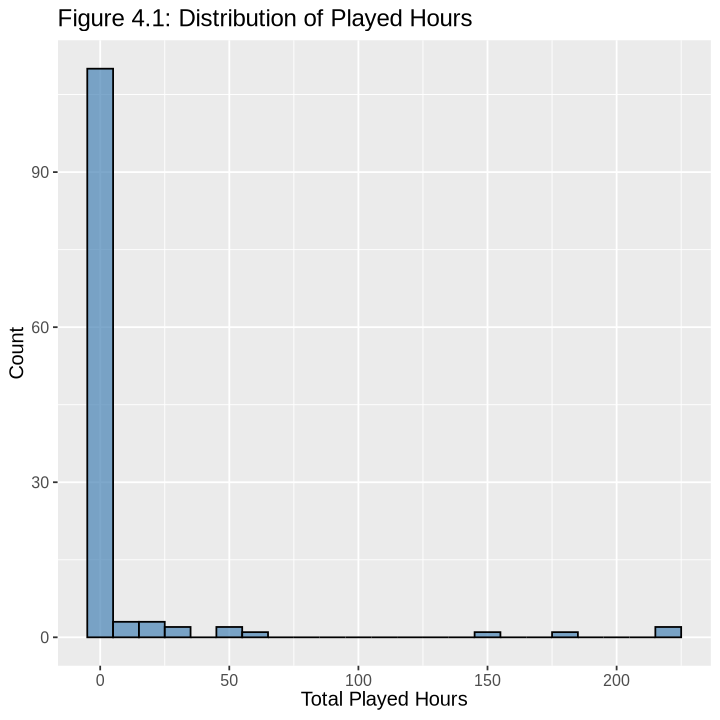

In [7]:
# Histogram for played_hours

ggplot(combined_play_data, aes(x = played_hours)) +
  geom_histogram(binwidth = 10, fill = "steelblue", color = "black", alpha = 0.7) +
  labs(title = "Figure 4.1: Distribution of Played Hours", 
       x = "Total Played Hours",
       y = "Count") +
  theme(text = element_text(size = 12))

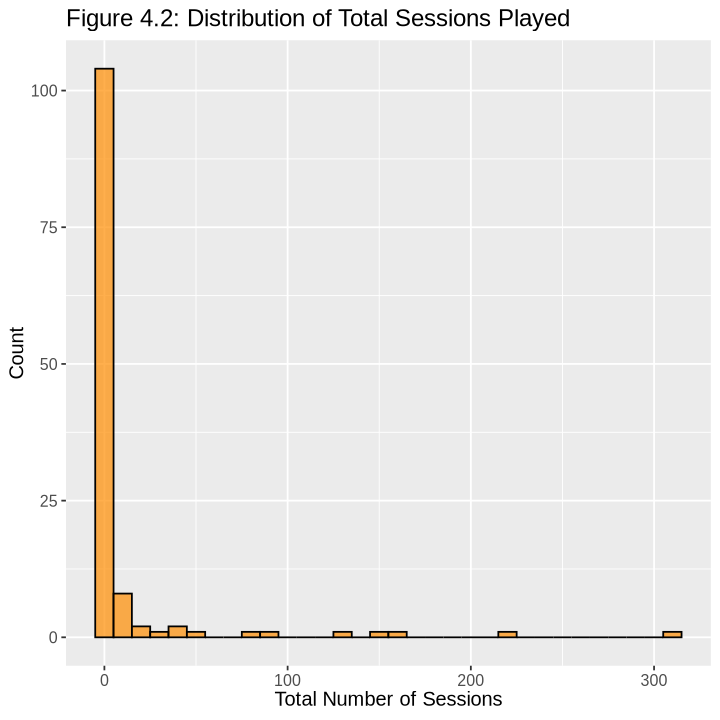

In [8]:
# Histogram for sessions_played
ggplot(combined_play_data, aes(x = sessions_played)) +
  geom_histogram(binwidth = 10, fill = "darkorange", color = "black", alpha = 0.7) +
  labs(title = "Figure 4.2: Distribution of Total Sessions Played", 
       x = "Total Number of Sessions",
       y = "Count") +
  theme(text = element_text(size = 12))

In [9]:
# Get the average/median played hours and average/median number of played sessions

## The MEAN will be used as the benchmark for setting threshold of highly contributive players
## (as the majority of player contributed 0 hours/sessions,
## median is not a good benchmark in this case)

cat(sprintf("Average played hours : %.2f \n", combined_play_data |> summarize(mean(played_hours)) |> pull()))
cat(sprintf("Average played sessions : %.2f \n", combined_play_data |> summarize(mean(sessions_played)) |> pull()))
cat(sprintf("Median played hours : %.2f \n", combined_play_data |> summarize(median(played_hours)) |> pull()))
cat(sprintf("Median played sessions : %.2f  \n", combined_play_data |> summarize(median(sessions_played)) |> pull()))

Average played hours : 9.17 
Average played sessions : 12.28 
Median played hours : 0.30 
Median played sessions : 1.00  


Warning message in scale_y_log10():
“log-10 transformation introduced infinite values.”


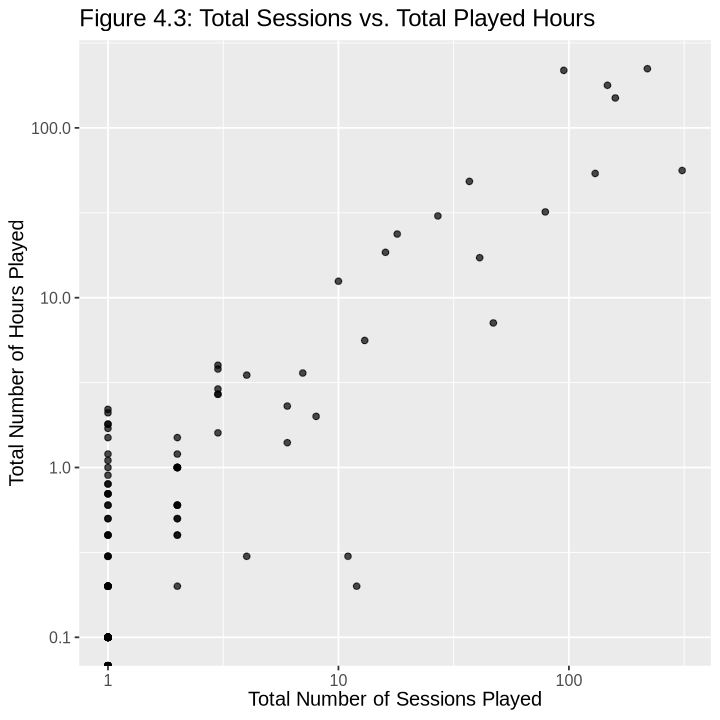

In [10]:
# Scatter plot for sessions_played vs. played_hours 

## Since there's big difference/gap between players in terms of hours/sessions played, 
## and the majority of players played 0 hours as seen from the above histograms, 
## scales are used here to make the relationship between played_hours and sessions_played in the scatter plot more apparent,
## And it appears there is a strong positive relationship, which is reasonable as more sessions could mean more hours played/spent

ggplot(combined_play_data, aes(x = sessions_played, y= played_hours)) +
  geom_point(alpha = 0.7) +
  labs(title = "Figure 4.3: Total Sessions vs. Total Played Hours", 
       x = "Total Number of Sessions Played",
       y = "Total Number of Hours Played") +
  scale_x_log10() +
  scale_y_log10()+
  theme(text = element_text(size = 12))

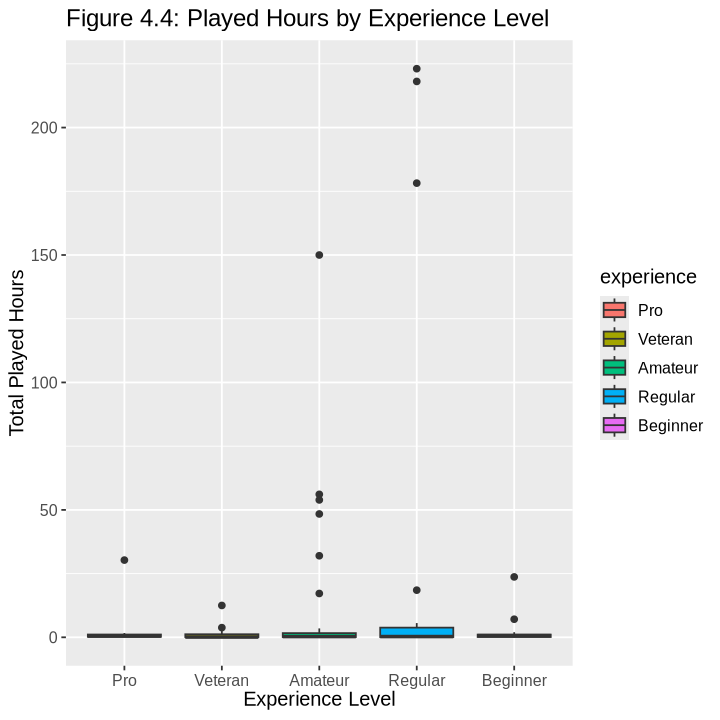

In [11]:
# Boxplot for played_hours by experience level
ggplot(combined_play_data, aes(x = experience, y = played_hours, fill = experience)) +
  geom_boxplot() +
  labs(title = "Figure 4.4: Played Hours by Experience Level", 
       x = "Experience Level", 
       y = "Total Played Hours") +
  theme(text = element_text(size = 12)) 

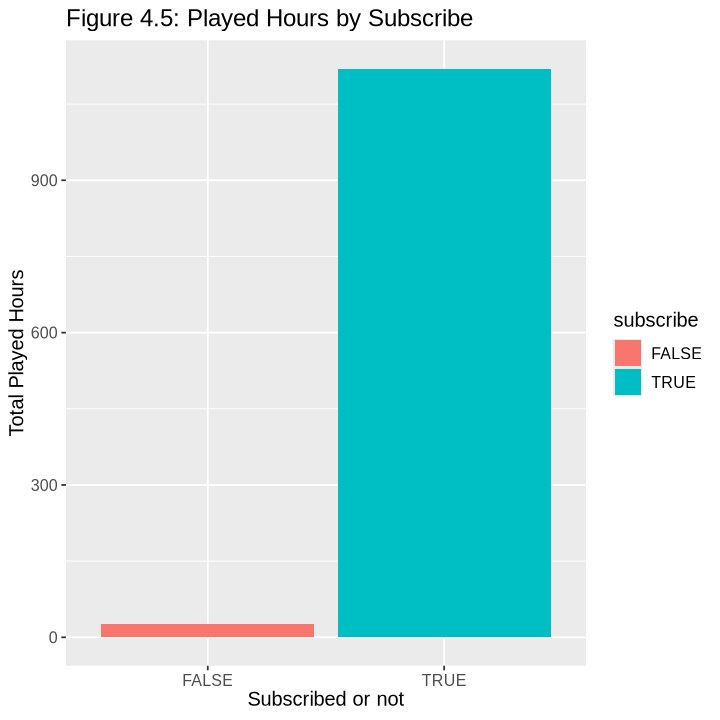

In [12]:
# Bar chart for played_hours vs subscribe 

ggplot(combined_play_data, aes(x = subscribe, y = played_hours, fill = subscribe)) +
  geom_bar(stat = "identity") +
  labs(title = "Figure 4.5: Played Hours by Subscribe", 
       x = "Subscribed or not", 
       y = "Total Played Hours") +
  theme(text = element_text(size = 12)) 

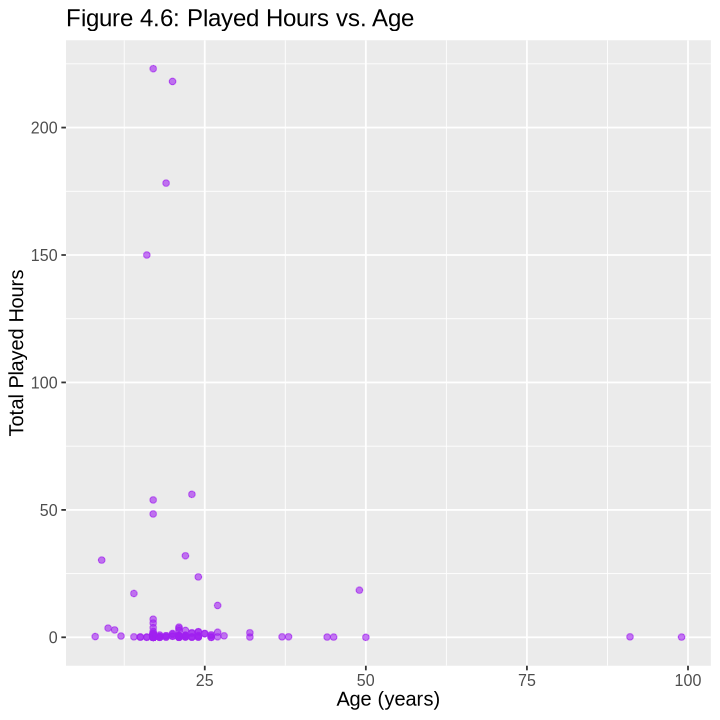

In [13]:
# Scatter plot for played_hours vs. age
ggplot(combined_play_data, aes(x = age, y = played_hours)) +
  geom_point(color = "purple", alpha = 0.6) +
  labs(title = "Figure 4.6: Played Hours vs. Age", 
       x = "Age (years)", 
       y = "Total Played Hours") +
  theme(text = element_text(size = 12)) 

## The Figure 4.6 below shows outlier players of age > 75, 
## who also contributed no play hours, 
## so they will be cleaned/excluded from the combined analysis
combined_play_data <- combined_play_data |>
    filter(age < 75)

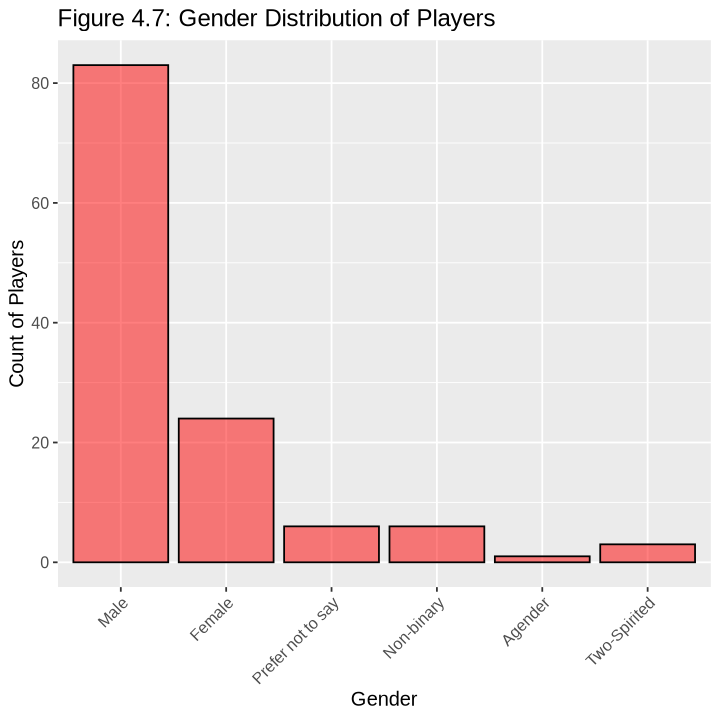

In [14]:
# Bar chart for the gender distribution

ggplot(combined_play_data, aes(x = gender)) +
  geom_bar(fill = "red", color = "black", alpha = 0.5) +
  labs(title = "Figure 4.7: Gender Distribution of Players", 
       x = "Gender", 
       y = "Count of Players") +
  theme(text = element_text(size = 12), axis.text.x = element_text(angle = 45, hjust = 1))



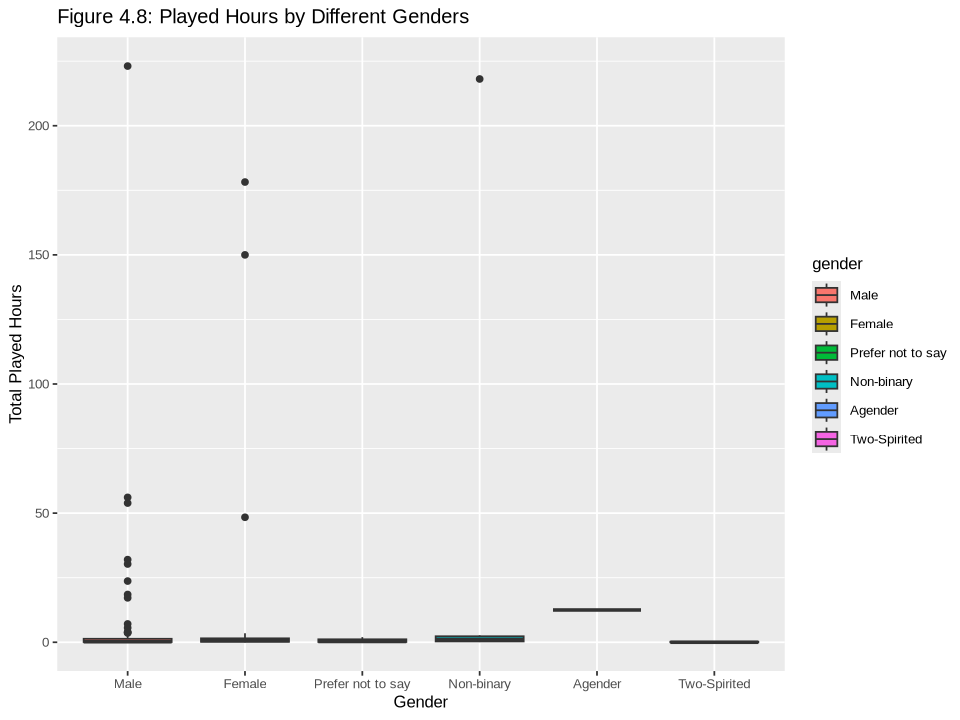

In [15]:
# Box Plot for total played_hours by gender group
options(repr.plot.width=8, repr.plot.height=6)
ggplot(combined_play_data, aes(x = gender, y = played_hours, fill = gender)) +
  geom_boxplot() +
  labs(title = "Figure 4.8: Played Hours by Different Genders", 
       x = "Gender", 
       y = "Total Played Hours") +
  theme(text = element_text(size = 10)) 

#### 5. performs the data analysis

The *Figure 4.3: Total Sessions vs. Total Played Hours* shows that there is a strong positive relationship, which is reasonable as more sessions could mean more hours played/spent. Hence, we could use just played_hours from the original players dataset as the target (as using both could be redundant).
The visualizations above show that the `played_hours` appears to be affected by every variable:
- **Experience**: Players categorized as 'Amateur' or 'Regular' tend to log higher `played_hours`, suggesting that experience level is associated with greater gameplay time, and there is variability within each experience category.
- **Subscribe**: Subscribed players (`subscribe = TRUE`) shows higher `played_hours`, suggesting that subscription to PlaiCraft's email updates encourages longer engagement compared to non-subscribed players. 
- **Gender**: There are differences in the distribution of `played_hours` across gender categories, and  the box plot shows males have a wider range of playtime.
- **Age**: The scatterplot of `age` versus `played_hours` shows that younger players around 20 tend to have longer playtime. However, age alone does not have a strong linear relationship with gameplay duration.


Also there is a clear imbalance in the dataset, with potential bias from a significant greater proportion of males. We'll thus balance the dataset for equal gender contribution.

In [16]:
summary(combined_play_data['gender'])

               gender  
 Male             :83  
 Female           :24  
 Prefer not to say: 6  
 Non-binary       : 6  
 Agender          : 1  
 Two-Spirited     : 3  
 Other            : 0  

In [17]:
# Balance the gender data distribution for later analysis
balanced_player_data <- upsample(combined_play_data, cat_col = 'gender')
summary(balanced_player_data['gender'])


               gender  
 Male             :83  
 Female           :83  
 Prefer not to say:83  
 Non-binary       :83  
 Agender          :83  
 Two-Spirited     :83  
 Other            : 0  

In [18]:
## create a binary target column high_contribution for KNN classification
## based on the threshold(mean of played_hours)
set.seed(123)
mean_played_hours <-  mean(balanced_player_data$played_hours)
mean_played_hours

classified_player_data <- balanced_player_data |>
    mutate(high_contribution = as_factor(played_hours >= mean_played_hours)) |>
    arrange(played_hours) |>
    select(-played_hours, -sessions_played) 

summary(classified_player_data['high_contribution'])

## Since there is imbalance for the target high_contribution, which could cause bias in prediction,
## so we will balance the dataset based on the target variable:
classified_player_data <- upsample(classified_player_data, cat_col = 'high_contribution')
summary(classified_player_data['high_contribution'])

head(classified_player_data)
tail(classified_player_data)

[1] 11.37711

 high_contribution
 FALSE:385        
 TRUE :113        

 high_contribution
 FALSE:385        
 TRUE :385        

,experience,subscribe,gender,age,high_contribution
,<fct>,<fct>,<fct>,<dbl>,<fct>
1,Veteran,FALSE,Male,17,FALSE
2,Amateur,FALSE,Male,21,FALSE
3,Regular,TRUE,Male,17,FALSE
4,Beginner,TRUE,Male,17,FALSE
5,Regular,FALSE,Male,18,FALSE
6,Amateur,TRUE,Male,16,FALSE


,experience,subscribe,gender,age,high_contribution
,<fct>,<fct>,<fct>,<dbl>,<fct>
765,Regular,TRUE,Male,17,TRUE
766,Veteran,TRUE,Agender,27,TRUE
767,Veteran,TRUE,Agender,27,TRUE
768,Veteran,TRUE,Agender,27,TRUE
769,Veteran,TRUE,Agender,27,TRUE
770,Veteran,TRUE,Agender,27,TRUE


#### 6. KNN analysis and visualization 
To address the question of identifying which "kinds" of players are most likely to contribute a large amount of data, we propose using the **K-Nearest Neighbors (KNN) classification** method. KNN is appropriate because it classifies players into **high** or **low** data contributors based on the similarity of their features, such as age, experience, gender, and sessions played. The target variable, **played_hours**, will be transformed into a binary column by setting a threshold (mean of the `played_hu) to distinguish between high and low data contributors.

The method assumes that players with similar characteristics will contribute similarly to playtime. Since KNN is based on distance metrics, it requires data to be scaled to ensure no single feature dominates the calculation. A key consideration is tuning the **k-value** (number of neighbors), which controls the balance between underfitting and overfitting. To select the optimal k, we will use **cross-validation** and evaluate performance metrics, such as accuracy or precision/recall, for various k-values.

The dataset will be split into **80% training** and **20% testing** sets. We will preprocess the data by handling missing values, encoding categorical variables, and scaling features. Cross-validation will be used to select the best model and fine-tune hyperparameters, including the k-value, to improve prediction accuracy.

In [19]:
# split the data for cross validation:
set.seed(123)
players_split <- initial_split(classified_player_data, prop = 0.8, strata = high_contribution)
players_train <- training(players_split)
players_test <- testing(players_split)
glimpse(players_train)
dim(players_test)

Rows: 616
Columns: 5
$ experience        <fct> Amateur, Beginner, Regular, Amateur, Regular, Amateu…
$ subscribe         <fct> FALSE, TRUE, FALSE, TRUE, FALSE, TRUE, TRUE, FALSE, …
$ gender            <fct> Male, Male, Male, Male, Male, Female, Female, Female…
$ age               <dbl> 21, 17, 18, 17, 50, 26, 17, 17, 17, 26, 26, 26, 17, …
$ high_contribution <fct> FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, FALSE, FAL…


[1] 154   5

In [20]:
# Tune the knn classifier
set.seed(123)
# -- DEBUGGING : cannot upsample FALSE/TRUE target variable, which will cause error in fitting--
players_recipe <- recipe(high_contribution ~ ., data = players_train) 
    # step_center(all_predictors())  # NECESSARY?


players_recipe

players_vfold <- vfold_cv(players_train, v = 5, strata = high_contribution)
# players_vfold  # -- DEBUGGING --

k_vals <- tibble(neighbors = seq(from = 1, to = 20, by = 1))

knn_spec <- nearest_neighbor(weight_func = "rectangular",
                             neighbors = tune()) |>
  set_engine("kknn") |>
  set_mode("classification")

knn_results <- workflow() |>
  add_recipe(players_recipe) |>
  add_model(knn_spec) |>
  tune_grid(resamples = players_vfold, grid = k_vals) |>
  collect_metrics()

accuracies <- knn_results |>
  filter(.metric == "accuracy") |>
  arrange(desc(mean))

accuracies



── Recipe ──────────────────────────────────────────────────────────────────────



── Inputs 

Number of variables by role

outcome:   1
predictor: 4



neighbors,.metric,.estimator,mean,n,std_err,.config
<dbl>,<chr>,<chr>,<dbl>,<int>,<dbl>,<chr>
3,accuracy,binary,0.9561872,5,0.006521026,Preprocessor1_Model03
4,accuracy,binary,0.9513485,5,0.004297787,Preprocessor1_Model04
6,accuracy,binary,0.9513221,5,0.008033399,Preprocessor1_Model06
5,accuracy,binary,0.9497091,5,0.006884146,Preprocessor1_Model05
11,accuracy,binary,0.9496563,5,0.009431466,Preprocessor1_Model11
12,accuracy,binary,0.9496563,5,0.009431466,Preprocessor1_Model12
13,accuracy,binary,0.9480698,5,0.006066821,Preprocessor1_Model13
14,accuracy,binary,0.9480698,5,0.006066821,Preprocessor1_Model14
9,accuracy,binary,0.9448704,5,0.005840417,Preprocessor1_Model09


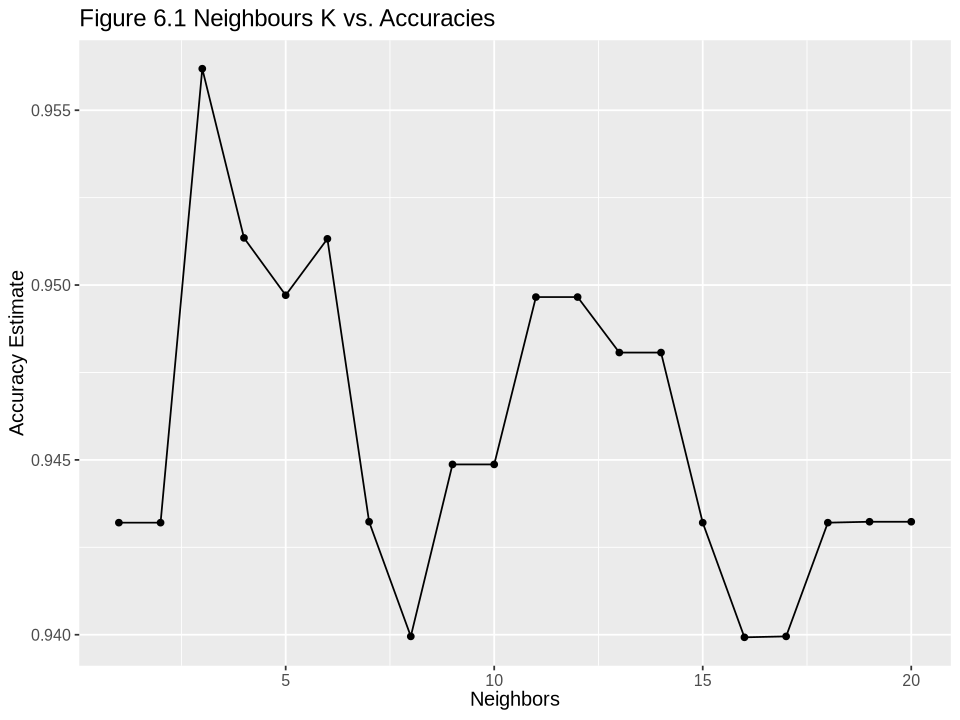

In [21]:
# Visualization for Neighbours K vs. Accuracies
accuracy_vs_k <- ggplot(accuracies, aes(x = neighbors, y = mean)) +
  geom_point() +
  geom_line() +
  labs(x = "Neighbors", y = "Accuracy Estimate", title="Figure 6.1 Neighbours K vs. Accuracies") +
  theme(text = element_text(size = 12))

accuracy_vs_k

In [22]:
# Get the best k from tuning results
best_k <- accuracies |>
        head(1) |>
        pull(neighbors)
best_k

[1] 3

In [23]:
## Evaluate on the test set
set.seed(123)
# Create a model with best_k
knn_spec_bestK <- nearest_neighbor(weight_func = "rectangular", neighbors = best_k) |>
  set_engine("kknn") |>
  set_mode("classification")

knn_fit_bestK <- workflow() |>
  add_recipe(players_recipe) |>
  add_model(knn_spec_bestK) |>
  fit(data = players_train)

knn_fit_bestK

# predict on test data set
players_test_predictions <- predict(knn_fit_bestK, players_test) |>
  bind_cols(players_test)

# get accuracies of training
players_test_predictions |>
  metrics(truth = high_contribution, estimate = .pred_class) |>
  filter(.metric == "accuracy")

══ Workflow [trained] ══════════════════════════════════════════════════════════
Preprocessor: Recipe
Model: nearest_neighbor()

── Preprocessor ────────────────────────────────────────────────────────────────
0 Recipe Steps

── Model ───────────────────────────────────────────────────────────────────────

Call:
kknn::train.kknn(formula = ..y ~ ., data = data, ks = min_rows(3,     data, 5), kernel = ~"rectangular")

Type of response variable: nominal
Minimal misclassification: 0.02922078
Best kernel: rectangular
Best k: 3

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.974026


In [24]:
# get the recall, precision metrics, and confusion matrix to verify the prediction results:
players_test_predictions |>
    recall(truth = high_contribution, estimate = .pred_class, event_level="second")

players_test_predictions |>
    precision(truth = high_contribution, estimate = .pred_class, event_level="second")

confusion <- players_test_predictions |>
             conf_mat(truth = high_contribution, estimate = .pred_class)
confusion

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
recall,binary,0.974026


.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
precision,binary,0.974026


          Truth
Prediction FALSE TRUE
     FALSE    75    2
     TRUE      2   75

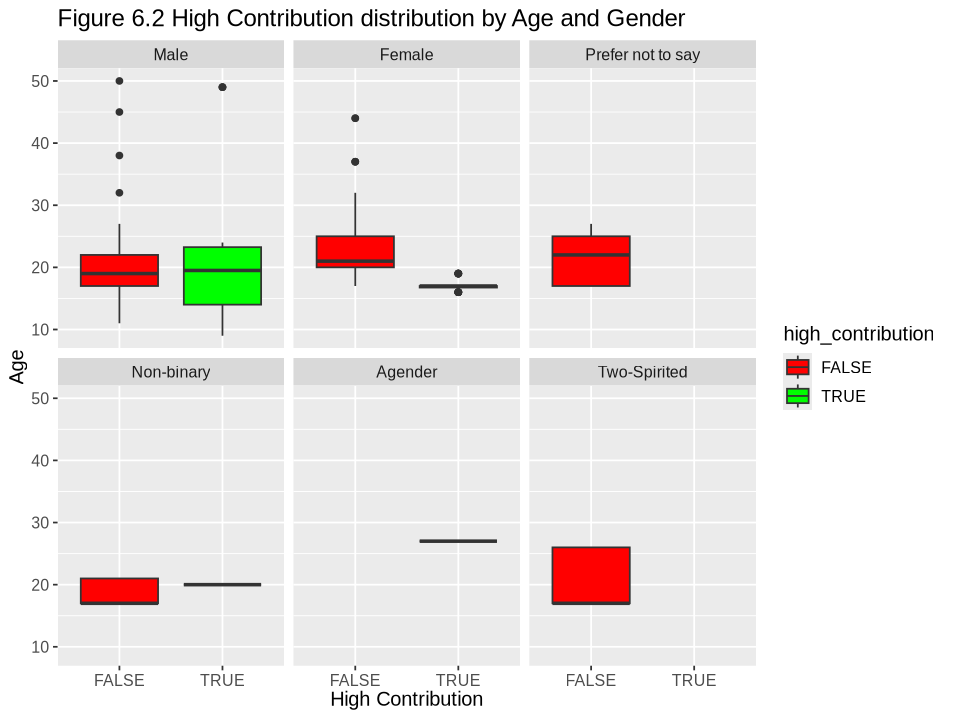

In [25]:
# Boxplot for 'age' by 'high_contribution', faceted by 'gender'
ggplot(players_train, aes(x = high_contribution, y = age, fill = high_contribution)) +
  geom_boxplot() +
  facet_wrap(~ gender) +
  labs(title = "Figure 6.2 High Contribution distribution by Age and Gender",
       x = "High Contribution", 
       y = "Age") +
  scale_fill_manual(values = c("red", "green")) +
  theme(text = element_text(size = 12))

## From the plot, it appears young (age < 25) male players have high contributions.

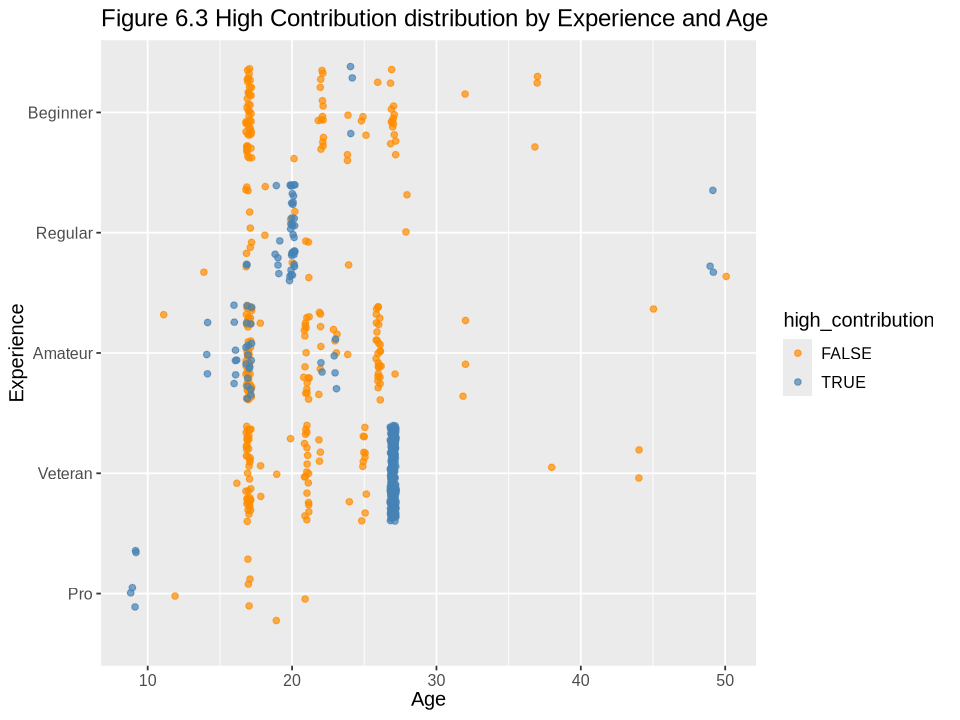

In [26]:
ggplot(players_train, aes(x = age, y = experience, color = high_contribution)) +
  geom_jitter(alpha = 0.7, width = 0.2) +
  labs(title = "Figure 6.3 High Contribution distribution by Experience and Age",
       x = "Age", 
       y = "Experience") +
  scale_color_manual(values = c("darkorange", "steelblue")) +
  theme(text = element_text(size = 12))
## From the plot, it appears young (age < 30) regular amateur and veteran players have high contributions

### Discussion
> ***(Checklist below):***
- [ ] summarize what you found
- [ ] discuss whether this is what you expected to find?
- [ ] discuss what impact could such findings have?
- [ ] discuss what future questions could this lead to?

### Reference